In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

In [2]:
data = fetch_california_housing(as_frame=True)
df = data.frame   # Pandas DataFrame containing features + target ('MedHouseVal')

In [3]:
print("First 5 records:\n", df.head())
print("\nLast 5 records:\n", df.tail())

First 5 records:
    MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Last 5 records:
        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      

In [4]:
print("\nDataset Info:")
df.info()
print("\nDescriptive Statistics:\n", df.describe())


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

Descriptive Statistics:
              MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846

In [5]:
# Independent variables (X): all columns except target
# Dependent variable (y): MedHouseVal (Median House Value)
X_all = df.drop(columns=['MedHouseVal'])
y_all = df['MedHouseVal']
print("\nIndependent variables:", list(X_all.columns))
print("Dependent variable: MedHouseVal")


Independent variables: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Dependent variable: MedHouseVal


In [6]:
from sklearn.model_selection import train_test_split
X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)
print(f"\nTraining set size: {X_train_all.shape[0]}, Testing set size: {X_test_all.shape[0]}")


Training set size: 16512, Testing set size: 4128


In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Using a single feature 'MedInc' (Median Income) to predict 'MedHouseVal'
X_simple = df[['MedInc']]
y_simple = df['MedHouseVal']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)


simple_lr = LinearRegression()

In [9]:
simple_lr.fit(X_train_s, y_train_s)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.42]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['MedInc']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.4446
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [10]:
y_pred_simple = simple_lr.predict(X_test_s)

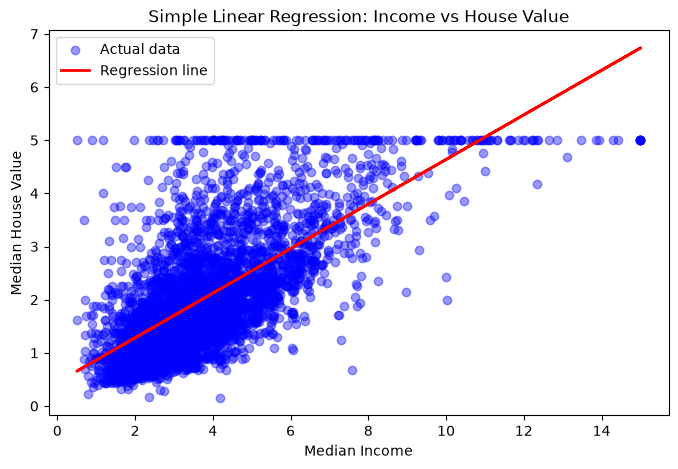

In [11]:
plt.figure(figsize=(8, 5))
plt.scatter(X_test_s, y_test_s, color='blue', alpha=0.4, label='Actual data')
plt.plot(X_test_s, y_pred_simple, color='red', linewidth=2, label='Regression line')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('Simple Linear Regression: Income vs House Value')
plt.legend()
plt.savefig('simple_linear_regression.png')
plt.show()

In [12]:
comparison_df = pd.DataFrame({'Actual': y_test_s.values[:10], 'Predicted': y_pred_simple[:10]})
print("\nActual vs Predicted (Simple LR):\n", comparison_df)


Actual vs Predicted (Simple LR):
     Actual  Predicted
0  0.47700   1.149589
1  0.45800   1.506069
2  5.00001   1.903937
3  2.18600   2.850594
4  2.78000   2.006633
5  1.58700   2.421652
6  1.98200   2.576472
7  1.57500   1.992292
8  3.40000   2.458932
9  4.46600   3.846774


In [13]:
print(f"\nCoefficient (slope): {simple_lr.coef_[0]:.4f}")
print(f"Intercept: {simple_lr.intercept_:.4f}")


Coefficient (slope): 0.4193
Intercept: 0.4446


In [17]:
new_income = np.array([[8.5]])   # e.g., median income = 8.5 (in tens of thousands)
predicted_value = simple_lr.predict(new_income)
print(f"\nPredicted house value for income=8.5: {predicted_value[0]:.4f}")


Predicted house value for income=8.5: 4.0090


c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [18]:
multi_lr = LinearRegression()

In [19]:
multi_lr.fit(X_train_all, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.45, 0.01,-0.12,...,-0. ,-0.42,-0.43]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['MedInc','HouseAge','AveRooms',...,'AveOccup','Latitude','Longitude']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-37.02
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [20]:
y_pred_multi = multi_lr.predict(X_test_all)

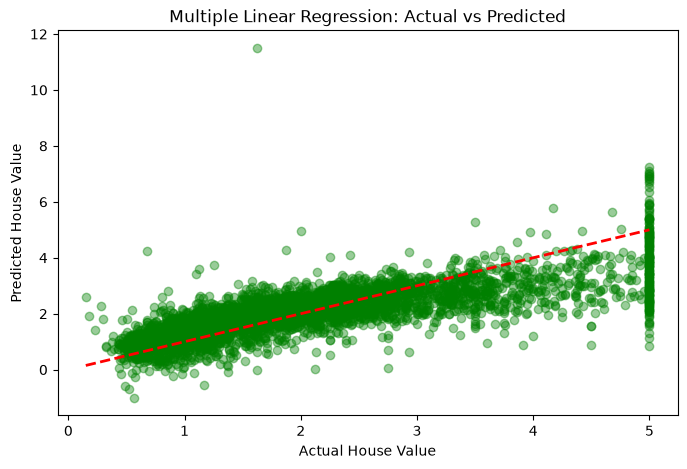

In [21]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_multi, alpha=0.4, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual House Value')
plt.ylabel('Predicted House Value')
plt.title('Multiple Linear Regression: Actual vs Predicted')
plt.savefig('multiple_linear_regression.png')
plt.show()

In [22]:
coeff_df = pd.DataFrame({
    'Feature': X_all.columns,
    'Coefficient': multi_lr.coef_
}).sort_values(by='Coefficient', ascending=False)
print("\nEffect of each feature on prediction:\n", coeff_df)


Effect of each feature on prediction:
       Feature  Coefficient
3   AveBedrms     0.783145
0      MedInc     0.448675
1    HouseAge     0.009724
4  Population    -0.000002
5    AveOccup    -0.003526
2    AveRooms    -0.123323
6    Latitude    -0.419792
7   Longitude    -0.433708


In [23]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline


In [24]:
poly2_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly2_model.fit(X_train_s, y_train_s)
print("Task 18: Polynomial Regression (Degree 2) model created and trained.")

Task 18: Polynomial Regression (Degree 2) model created and trained.


In [25]:
poly3_model = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())
poly3_model.fit(X_train_s, y_train_s)
print("Task 19: Polynomial Regression (Degree 3) model created and trained.")

Task 19: Polynomial Regression (Degree 3) model created and trained.


In [26]:
y_pred_linear_compare = simple_lr.predict(X_test_s)
y_pred_poly2_compare = poly2_model.predict(X_test_s)
y_pred_poly3_compare = poly3_model.predict(X_test_s)

r2_linear = r2_score(y_test_s, y_pred_linear_compare)
r2_poly2 = r2_score(y_test_s, y_pred_poly2_compare)
r2_poly3 = r2_score(y_test_s, y_pred_poly3_compare)

print("Task 20: Comparison of R² scores")
print(f"Linear Regression R²      : {r2_linear:.4f}")
print(f"Polynomial Degree 2 R²    : {r2_poly2:.4f}")
print(f"Polynomial Degree 3 R²    : {r2_poly3:.4f}")

Task 20: Comparison of R² scores
Linear Regression R²      : 0.4589
Polynomial Degree 2 R²    : 0.4633
Polynomial Degree 3 R²    : 0.4671


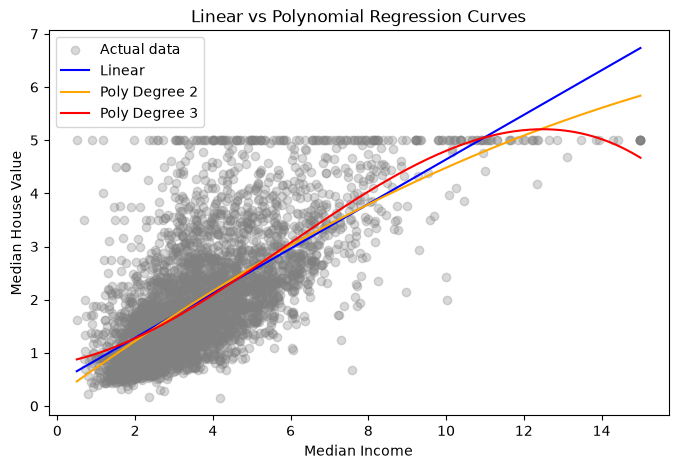

Task 21: Polynomial regression curves visualized.


In [27]:
X_range = np.linspace(X_simple.min(), X_simple.max(), 300).reshape(-1, 1)
X_range_df = pd.DataFrame(X_range, columns=['MedInc'])
plt.figure(figsize=(8, 5))
plt.scatter(X_test_s, y_test_s, color='gray', alpha=0.3, label='Actual data')
plt.plot(X_range_df, simple_lr.predict(X_range_df), color='blue', label='Linear')
plt.plot(X_range_df, poly2_model.predict(X_range_df), color='orange', label='Poly Degree 2')
plt.plot(X_range_df, poly3_model.predict(X_range_df), color='red', label='Poly Degree 3')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('Linear vs Polynomial Regression Curves')
plt.legend()
plt.savefig('polynomial_regression.png')
plt.show()
print("Task 21: Polynomial regression curves visualized.")

In [28]:
y_pred_poly2 = poly2_model.predict(X_test_s)
y_pred_poly3 = poly3_model.predict(X_test_s)

print("Task 22: Predictions using Polynomial Regression models")
print("\nPoly Degree 2 - first 10 predictions:\n", y_pred_poly2[:10])
print("\nPoly Degree 3 - first 10 predictions:\n", y_pred_poly3[:10])

Task 22: Predictions using Polynomial Regression models

Poly Degree 2 - first 10 predictions:
 [1.06494053 1.4809167  1.92725435 2.91317577 2.03938915 2.47971336
 2.638701   2.02380537 2.51825798 3.83502004]

Poly Degree 3 - first 10 predictions:
 [1.17023574 1.4643903  1.85513131 2.93935648 1.9644378  2.43147376
 2.61306574 1.94899636 2.47493443 4.08459407]


In [29]:
mae_poly2 = mean_absolute_error(y_test_s, y_pred_poly2)
mae_poly3 = mean_absolute_error(y_test_s, y_pred_poly3)
rmse_poly2 = np.sqrt(mean_squared_error(y_test_s, y_pred_poly2))
rmse_poly3 = np.sqrt(mean_squared_error(y_test_s, y_pred_poly3))

accuracy_comparison = pd.DataFrame({
    'Degree': [2, 3],
    'MAE': [mae_poly2, mae_poly3],
    'RMSE': [rmse_poly2, rmse_poly3],
    'R2': [r2_poly2, r2_poly3]
})
print("Task 23: Prediction accuracy comparison across polynomial degrees")
print(accuracy_comparison)

Task 23: Prediction accuracy comparison across polynomial degrees
   Degree       MAE      RMSE        R2
0       2  0.628292  0.838614  0.463318
1       3  0.621896  0.835641  0.467116


In [30]:
def evaluate_model(y_true, y_pred, model_name):
    """Calculate and print MAE, MSE, RMSE, R2 for a given model's predictions."""
    mae = mean_absolute_error(y_true, y_pred)          # Task 24
    mse = mean_squared_error(y_true, y_pred)            # Task 25
    rmse = np.sqrt(mse)                                  # Task 26
    r2 = r2_score(y_true, y_pred)                        # Task 27
    print(f"\n--- {model_name} ---")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")
    return {'Model': model_name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

In [31]:
results = []
results.append(evaluate_model(y_test_s, y_pred_simple, "Simple Linear Regression"))
results.append(evaluate_model(y_test, y_pred_multi, "Multiple Linear Regression"))
results.append(evaluate_model(y_test_s, y_pred_poly2, "Polynomial Regression (Degree 2)"))
results.append(evaluate_model(y_test_s, y_pred_poly3, "Polynomial Regression (Degree 3)"))

results_df = pd.DataFrame(results)
print("\nComparison Table:\n", results_df)


--- Simple Linear Regression ---
MAE  : 0.6299
MSE  : 0.7091
RMSE : 0.8421
R²   : 0.4589

--- Multiple Linear Regression ---
MAE  : 0.5332
MSE  : 0.5559
RMSE : 0.7456
R²   : 0.5758

--- Polynomial Regression (Degree 2) ---
MAE  : 0.6283
MSE  : 0.7033
RMSE : 0.8386
R²   : 0.4633

--- Polynomial Regression (Degree 3) ---
MAE  : 0.6219
MSE  : 0.6983
RMSE : 0.8356
R²   : 0.4671

Comparison Table:
                               Model       MAE       MSE      RMSE        R2
0          Simple Linear Regression  0.629909  0.709116  0.842090  0.458859
1        Multiple Linear Regression  0.533200  0.555892  0.745581  0.575788
2  Polynomial Regression (Degree 2)  0.628292  0.703273  0.838614  0.463318
3  Polynomial Regression (Degree 3)  0.621896  0.698296  0.835641  0.467116


In [32]:
print("""
Interpretation:
- Lower MSE/RMSE indicates the model's predictions are closer to actual values (less error).
- R² closer to 1 means the model explains most of the variance in the target variable.
- R² closer to 0 (or negative) means the model performs poorly / no better than predicting the mean.
""")



Interpretation:
- Lower MSE/RMSE indicates the model's predictions are closer to actual values (less error).
- R² closer to 1 means the model explains most of the variance in the target variable.
- R² closer to 0 (or negative) means the model performs poorly / no better than predicting the mean.



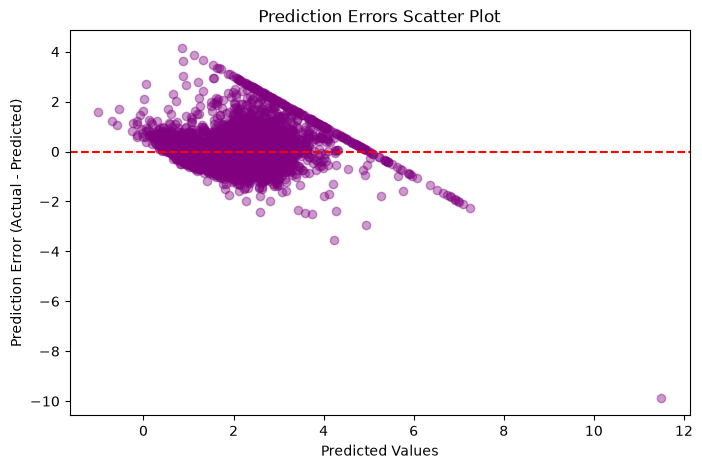

In [33]:
errors = y_test - y_pred_multi
plt.figure(figsize=(8, 5))
plt.scatter(y_pred_multi, errors, alpha=0.4, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Prediction Error (Actual - Predicted)')
plt.title('Prediction Errors Scatter Plot')
plt.savefig('prediction_errors.png')
plt.show()

In [34]:
from sklearn.preprocessing import StandardScaler
import joblib

In [35]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_all)
X_test_scaled = scaler.transform(X_test_all)

scaled_model = LinearRegression()
scaled_model.fit(X_train_scaled, y_train)
y_pred_scaled = scaled_model.predict(X_test_scaled)

In [36]:
before_scaling = evaluate_model(y_test, y_pred_multi, "Before Scaling (Multiple LR)")
after_scaling = evaluate_model(y_test, y_pred_scaled, "After Scaling (Multiple LR)")


--- Before Scaling (Multiple LR) ---
MAE  : 0.5332
MSE  : 0.5559
RMSE : 0.7456
R²   : 0.5758

--- After Scaling (Multiple LR) ---
MAE  : 0.5332
MSE  : 0.5559
RMSE : 0.7456
R²   : 0.5758


In [37]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes(as_frame=True)
df_diabetes = diabetes.frame
X_diab = df_diabetes.drop(columns=['target'])
y_diab = df_diabetes['target']
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_diab, y_diab, test_size=0.2, random_state=42
)
diabetes_model = LinearRegression()
diabetes_model.fit(X_train_d, y_train_d)
y_pred_diab = diabetes_model.predict(X_test_d)
evaluate_model(y_test_d, y_pred_diab, "Diabetes Dataset - Linear Regression")


--- Diabetes Dataset - Linear Regression ---
MAE  : 42.7941
MSE  : 2900.1936
RMSE : 53.8534
R²   : 0.4526


{'Model': 'Diabetes Dataset - Linear Regression',
 'MAE': 42.79409467959994,
 'MSE': 2900.1936284934795,
 'RMSE': np.float64(53.85344583676591),
 'R2': 0.4526027629719198}

In [38]:
joblib.dump(multi_lr, 'multiple_linear_regression_model.joblib')
joblib.dump(scaler, 'feature_scaler.joblib')   # save scaler too, useful for future predictions
print("\nModel saved as 'multiple_linear_regression_model.joblib'")



Model saved as 'multiple_linear_regression_model.joblib'


In [39]:
loaded_model = joblib.load('multiple_linear_regression_model.joblib')
sample_input = X_test_all.iloc[[0]]   # take one sample row from test set
loaded_prediction = loaded_model.predict(sample_input)
print(f"\nPrediction using loaded model: {loaded_prediction[0]:.4f}")
print(f"Actual value for this sample: {y_test.iloc[0]:.4f}")


Prediction using loaded model: 0.7191
Actual value for this sample: 0.4770
